# Predicting Student Performance — Part A: EDA & Preprocessing
**Author:** Aleida
**Date:** September 2026

**Goal:** Explore the UCI Student Performance (Math) dataset and prepare it for modeling. Target variable: **G3** (final grade, 0–20).

## 0. Setup
Import libraries and set a fixed random seed so results can be reproduced.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42  # use the same seed as Part B

# Consistent plot style for every figure
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "axes.grid": True, "grid.alpha": 0.3})
BLUE, ORANGE, GREEN, RED = '#2a78d6', '#eb6834', '#1baf7a', '#e34948'

## 1. Data Loading
**TODO:**
- Load `student-mat.csv` (note: the file uses **`;`** as separator → `sep=";"`)
- Check shape (expected: 395 rows × 33 columns), first rows, data types, missing values

In [2]:
# Load the dataset
# The original UCI file uses ';' as separator. sep=None lets pandas detect it,
# so this also works if someone uses a comma-separated copy of the file.
df = pd.read_csv("student-mat.csv", sep=None, engine="python")

In [3]:
# Shape, head, info
print("Shape:", df.shape)   # expected (395, 33)
df.info()
df.head()

Shape: (395, 33)
<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null  

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
# Check for missing values
print("Total missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Total missing values: 0
Duplicate rows: 0


**Observations:**

- The dataset has **395 students and 33 columns**, as expected.
- **16 columns are numeric** (age, grades, 1–5 ratings, counts) and **17 are text/categorical** (school, sex, parents' jobs, yes/no answers).
- There are **no missing values and no duplicate rows**, so no rows need to be dropped or filled.

## 2. Descriptive Statistics
**TODO:** Compute **mean, median, standard deviation** for key numeric features:
`age`, `absences`, `studytime`, `failures`, `G1`, `G2`, `G3`

In [5]:
# Descriptive statistics (mean, median, std)
key_features = ["age", "absences", "studytime", "failures", "G1", "G2", "G3"]
desc = df[key_features].agg(["mean", "median", "std", "min", "max"]).T.round(2)
desc

,mean,median,std,min,max
age,16.70,17.0,1.28,15.0,22.0
absences,5.71,4.0,8.00,0.0,75.0
studytime,2.04,2.0,0.84,1.0,4.0
failures,0.33,0.0,0.74,0.0,3.0
G1,10.91,11.0,3.32,3.0,19.0
G2,10.71,11.0,3.76,0.0,19.0
G3,10.42,11.0,4.58,0.0,20.0


**Observations:**

- **Grades** average about 10.5 out of 20 (G1 = 10.91, G2 = 10.71, G3 = 10.42). G3 has the widest spread (std = 4.58).
- G3's **mean (10.42) is below its median (11)** — a group of zero grades pulls the average down (see the histogram below).
- **Absences** are right-skewed: median 4 and mean 5.71, but the maximum is 75.
- Most students have **0 past failures** (median 0, mean 0.33) and study **2–5 hours a week** (studytime median 2).
- Students are **15–22 years old**, mostly 16–17 (mean 16.7).

## 3. Visualizations
Every plot needs a **title, axis labels, and legend** (where applicable).

### 3.1 Distribution of Final Grade (G3) — Histogram
**Hint:** Look for the cluster of students with G3 = 0 and count them.

Students with G3 = 0: 38 (9.6%)


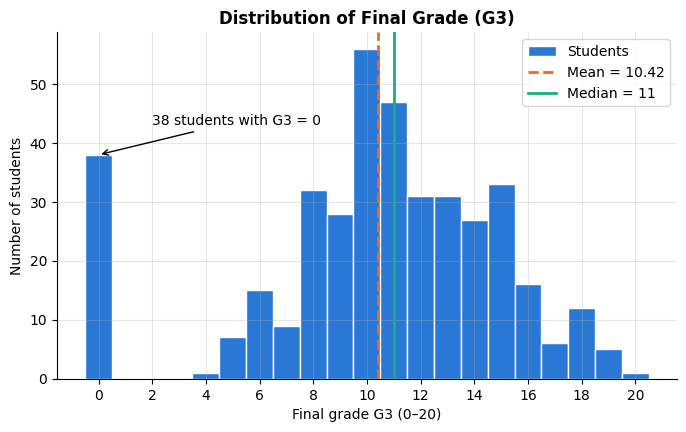

In [6]:
# Histogram of G3
n_zero = (df["G3"] == 0).sum()
print(f"Students with G3 = 0: {n_zero} ({n_zero / len(df):.1%})")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df["G3"], bins=np.arange(-0.5, 21.5, 1), color=BLUE, edgecolor="white", label="Students")
ax.axvline(df["G3"].mean(), color=ORANGE, ls="--", lw=2, label=f"Mean = {df['G3'].mean():.2f}")
ax.axvline(df["G3"].median(), color=GREEN, lw=2, label=f"Median = {df['G3'].median():.0f}")
ax.annotate(f"{n_zero} students with G3 = 0", xy=(0, n_zero), xytext=(2, n_zero + 5),
            arrowprops=dict(arrowstyle="->"))
ax.set_title("Distribution of Final Grade (G3)")
ax.set_xlabel("Final grade G3 (0–20)")
ax.set_ylabel("Number of students")
ax.set_xticks(range(0, 21, 2))
ax.legend()
plt.show()

**Observations:**

- Apart from zeros, G3 is **roughly bell-shaped**, with most grades between 8 and 15.
- **38 students (9.6%) have G3 = 0.** No one scored 1–3, so these zeros are separated from the rest of the distribution.
- All 38 of these students have **0 recorded absences**, and 13 already had G2 = 0. This suggests they **dropped the course or skipped the final exam** rather than truly scoring zero. These students will be the hardest for any model to predict.

### 3.2 Correlation Heatmap (numeric features)

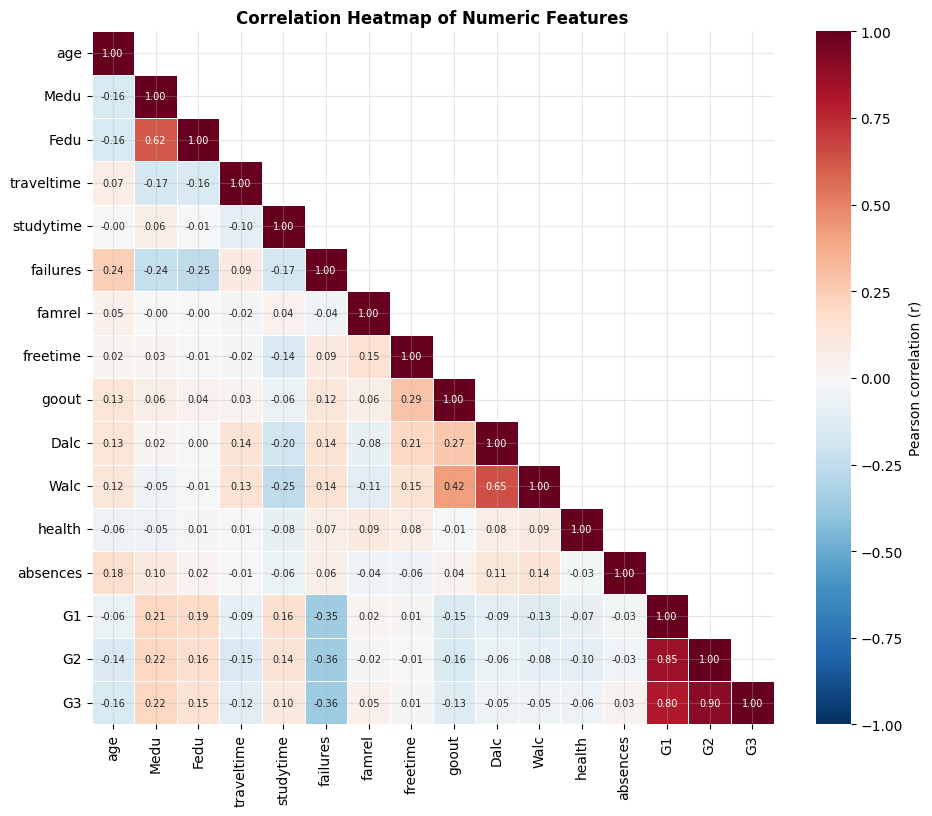

In [7]:
# Correlation heatmap
num_cols = df.select_dtypes(include="number").columns
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # show lower triangle only
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot_kws={"size": 7}, linewidths=0.5, cbar_kws={"label": "Pearson correlation (r)"}, ax=ax)
ax.set_title("Correlation Heatmap of Numeric Features")
plt.show()

**Observations:**

- **G2 (r = 0.90) and G1 (r = 0.80)** have by far the strongest correlation with G3. Earlier grades are the best predictor of the final grade.
- G1 and G2 are also strongly correlated with each other (r = 0.85), so they carry overlapping information.
- **Failures** is the strongest non-grade feature (r = −0.36): more past failures → lower final grade.
- **Mother's education** (r = 0.22) and **father's education** (r = 0.15) are mildly positive; **age, going out and travel time** are mildly negative.
- Weekday and weekend alcohol use (Dalc, Walc) correlate with each other (r = 0.65) but barely with G3. Absences have almost no linear relationship with G3 (r = 0.03).

### 3.3 Box Plot — G3 by Study Time / Failures

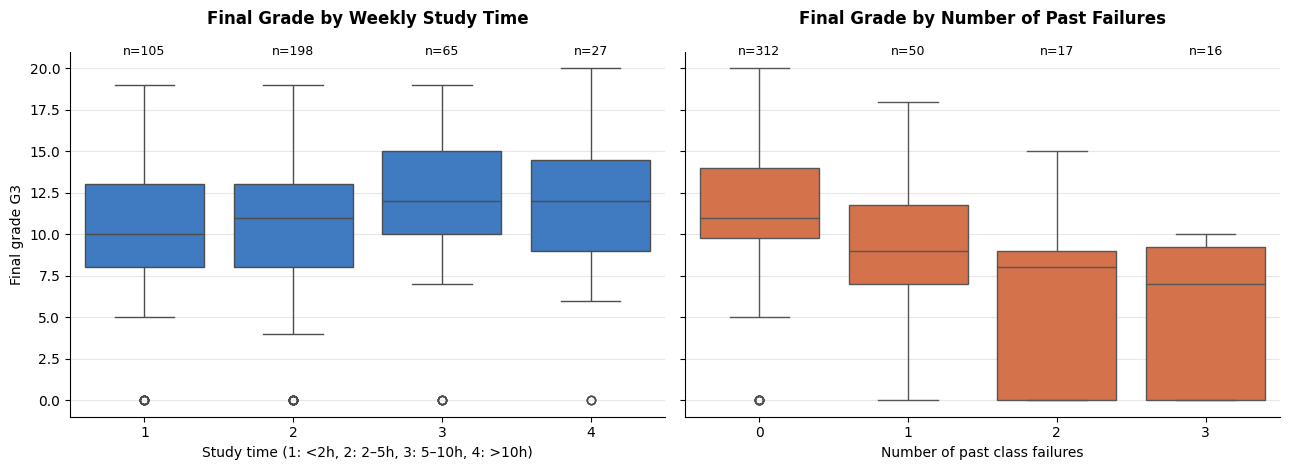

           count  median   mean
studytime                      
1            105    10.0  10.05
2            198    11.0  10.17
3             65    12.0  11.40
4             27    12.0  11.26
          count  median   mean
failures                      
0           312    11.0  11.25
1            50     9.0   8.12
2            17     8.0   6.24
3            16     7.0   5.69


In [8]:
# Box plot(s)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)

sns.boxplot(data=df, x="studytime", y="G3", color=BLUE, ax=axes[0])
axes[0].set_title("Final Grade by Weekly Study Time", pad=20)
axes[0].set_xlabel("Study time (1: <2h, 2: 2–5h, 3: 5–10h, 4: >10h)")
axes[0].set_ylabel("Final grade G3")

sns.boxplot(data=df, x="failures", y="G3", color=ORANGE, ax=axes[1])
axes[1].set_title("Final Grade by Number of Past Failures", pad=20)
axes[1].set_xlabel("Number of past class failures")
axes[1].set_ylabel("Final grade G3")

# Show group sizes above each box
for ax, col in zip(axes, ["studytime", "failures"]):
    for i, n in enumerate(df[col].value_counts().sort_index()):
        ax.text(i, 20.8, f"n={n}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(df.groupby("studytime")["G3"].agg(["count", "median", "mean"]).round(2))
print(df.groupby("failures")["G3"].agg(["count", "median", "mean"]).round(2))

**Observations:**

- **Study time:** median G3 rises from 10 (<2 hours/week) to 12 (5+ hours/week), but the boxes overlap a lot. Study time has only a weak effect (r = 0.10).
- **Failures:** median G3 drops steadily from 11 (0 failures) to 9, 8 and 7 (1, 2, 3 failures). This is a much clearer pattern.
- Groups with more failures are small (only 17 and 16 students with 2 and 3 failures), so their boxes are less reliable.
- Zero-grade outliers appear in every group, showing that dropping out is not limited to one type of student.

### 3.4 Scatter Plot — G2 vs. G3

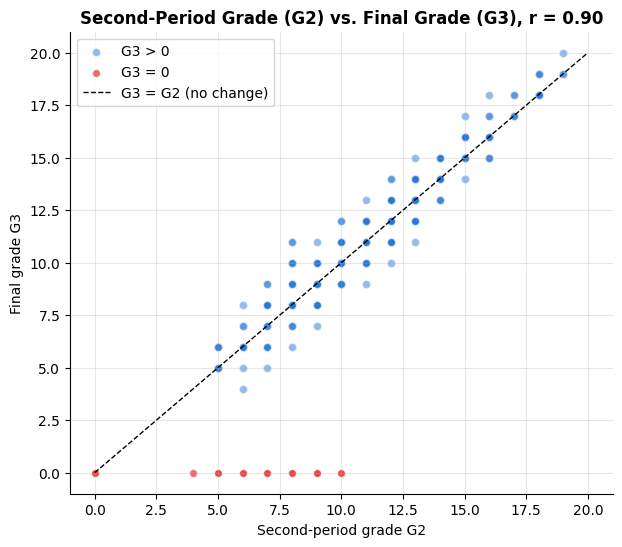

In [9]:
# Scatter plot
zero = df["G3"] == 0
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df.loc[~zero, "G2"], df.loc[~zero, "G3"], color=BLUE, alpha=0.5, edgecolor="white", label="G3 > 0")
ax.scatter(df.loc[zero, "G2"], df.loc[zero, "G3"], color=RED, alpha=0.8, edgecolor="white", label="G3 = 0")
ax.plot([0, 20], [0, 20], "k--", lw=1, label="G3 = G2 (no change)")
ax.set_title(f"Second-Period Grade (G2) vs. Final Grade (G3), r = {df['G2'].corr(df['G3']):.2f}")
ax.set_xlabel("Second-period grade G2")
ax.set_ylabel("Final grade G3")
ax.legend()
plt.show()

**Observations:**

- For almost all students, G3 is **very close to G2**: the points lie along the diagonal. This explains the r = 0.90 correlation.
- The **red points** are students with G2 between 4 and 10 but a final grade of 0. They break the straight-line pattern and will cause the largest prediction errors.
- Because G2 is so predictive, a model with G1/G2 will score high. A model without them shows how well background features alone can predict grades.

## 4. Data Preprocessing

### 4.1 Identify Categorical vs. Numerical Columns
**TODO:** Split column names into categorical (object dtype, e.g. `school`, `sex`, `address`, `Mjob`) and numerical.

In [10]:
# Identify column types
categorical_cols = df.select_dtypes(exclude="number").columns.tolist()
numerical_cols = df.select_dtypes(include="number").columns.tolist()

print(f"Categorical ({len(categorical_cols)}):", categorical_cols)
print(f"Numerical ({len(numerical_cols)}):", numerical_cols)

# How many categories each text column has
df[categorical_cols].nunique().sort_values()

Categorical (17): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Numerical (16): ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


school        2
sex           2
address       2
famsize       2
Pstatus       2
paid          2
famsup        2
schoolsup     2
higher        2
nursery       2
internet      2
activities    2
romantic      2
guardian      3
reason        4
Fjob          5
Mjob          5
dtype: int64

### 4.2 Encode Categorical Variables
**TODO:** One-hot encode with `pd.get_dummies(..., drop_first=True)`.

**Why is this necessary?**
- **ML models need numeric input.** scikit-learn cannot use text values like `"GP"` or `"teacher"` directly.
- **One-hot avoids implying a false order.** Numbering parents' jobs as 0, 1, 2, 3 would tell the model that "teacher" is somehow "more" than "at_home". One-hot gives each category its own 0/1 column instead.
- **`drop_first=True` avoids redundant columns.** If a student isn't in any of the other job categories, the dropped one is implied. Keeping all of them would make the columns perfectly collinear (the "dummy variable trap"), which breaks Linear Regression.
- 13 of the 17 categorical columns have only 2 values (e.g. yes/no), so each becomes a single 0/1 column. The 4 multi-category columns (`Mjob`, `Fjob`, `reason`, `guardian`) become several columns.
- **Numeric columns are left as they are.** `Medu`, `Fedu` and the 1–5 ratings are already numbers where the order matters (e.g. more education = higher number).

In [11]:
# One-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

print("Before encoding:", df.shape)
print("After encoding: ", df_encoded.shape)   # 33 columns -> 42 (41 features + G3)
new_cols = [c for c in df_encoded.columns if c not in df.columns]
print(f"New dummy columns ({len(new_cols)}):", new_cols)
assert df_encoded.isnull().sum().sum() == 0
df_encoded.head()

Before encoding: (395, 33)
After encoding:  (395, 42)
New dummy columns (26): ['school_MS', 'sex_M', 'address_U', 'famsize_LE3', 'Pstatus_T', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother', 'guardian_other', 'schoolsup_yes', 'famsup_yes', 'paid_yes', 'activities_yes', 'nursery_yes', 'higher_yes', 'internet_yes', 'romantic_yes']


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,1,0,1,0,0,0,1,1,0,0
1,17,1,1,1,2,0,5,3,3,1,...,0,0,0,1,0,0,0,1,1,0
2,15,1,1,1,2,3,4,3,2,2,...,1,0,1,0,1,0,1,1,1,0
3,15,4,2,1,3,0,3,2,2,1,...,1,0,0,1,1,1,1,1,1,1
4,16,3,3,1,2,0,4,3,2,1,...,0,0,0,1,1,0,1,1,0,0


### 4.3 Normalization / Standardization
**TODO:** Explain the scaling decision (the actual scaling is done in Part B *after* the train/test split, to avoid data leakage).

**Why?**
- **Linear Regression:** features are on very different scales (absences 0–75, grades 0–20, dummy columns 0–1). Without scaling, the size of each coefficient depends on the unit of the feature, so they can't be compared fairly. → use `StandardScaler` (mean 0, standard deviation 1).
- **Decision Tree / Random Forest:** they split on thresholds (e.g. "G2 ≤ 9.5"), so scaling doesn't change the result → scaling not required.
- **Why scale after the split:** the scaler must learn the mean and std from the **training set only**. Scaling before the split would let information from the test set leak into training and make results look better than they really are.
- The cell below only **demonstrates** what scaling does on a copy; `processed_data.csv` is saved **unscaled**.

In [12]:
# (Optional) demonstrate StandardScaler on a copy of the numeric features
demo_cols = ["age", "absences", "studytime", "G1", "G2"]
scaled_demo = pd.DataFrame(StandardScaler().fit_transform(df[demo_cols]), columns=demo_cols)

comparison = pd.DataFrame({
    "original mean": df[demo_cols].mean(), "original std": df[demo_cols].std(),
    "scaled mean": scaled_demo.mean(), "scaled std": scaled_demo.std(ddof=0),
}).round(2)
comparison

,original mean,original std,scaled mean,scaled std
age,16.70,1.28,0.0,1.0
absences,5.71,8.00,-0.0,1.0
studytime,2.04,0.84,-0.0,1.0
G1,10.91,3.32,0.0,1.0
G2,10.71,3.76,-0.0,1.0


## 5. Feature Importance — Correlation Analysis
**TODO:** Correlation of each feature with G3, sorted; show as a bar chart. (Part B adds model-based importance from Random Forest.)

In [13]:
# Correlation with G3 (sorted)
corr_with_g3 = df_encoded.corr()["G3"].drop("G3")
corr_sorted = corr_with_g3.reindex(corr_with_g3.abs().sort_values(ascending=False).index)
corr_sorted.round(3).to_frame("r with G3").head(15)

,r with G3
G2,0.905
G1,0.801
failures,-0.360
Medu,0.217
higher_yes,0.182
age,-0.162
Fedu,0.152
goout,-0.133
romantic_yes,-0.130
traveltime,-0.117


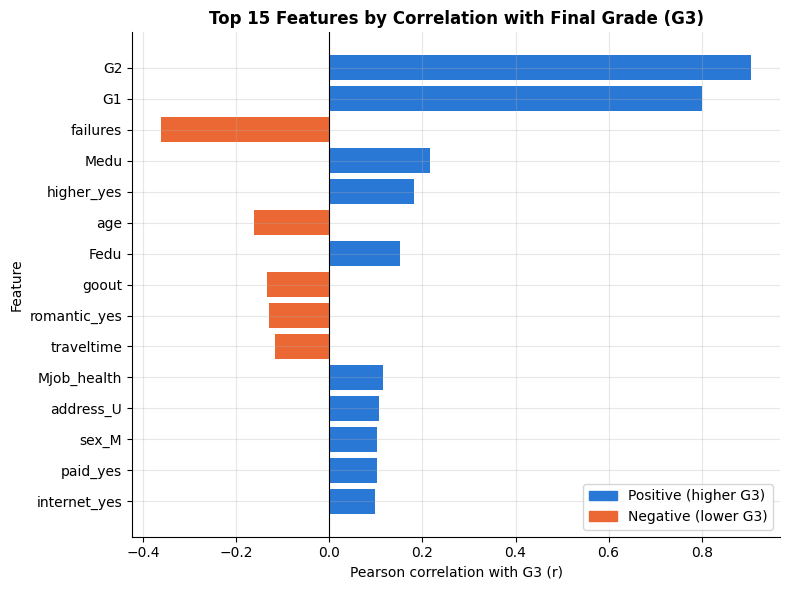

In [14]:
# Bar chart of correlations
top = corr_sorted.head(15)[::-1]   # top 15 by absolute value, strongest at the top
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(top.index, top.values, color=[BLUE if v > 0 else ORANGE for v in top.values])
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Top 15 Features by Correlation with Final Grade (G3)")
ax.set_xlabel("Pearson correlation with G3 (r)")
ax.set_ylabel("Feature")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=BLUE, label="Positive (higher G3)"),
                   Patch(color=ORANGE, label="Negative (lower G3)")], loc="lower right")
plt.tight_layout()
plt.show()

**Observations:**

- **G2 (0.90) and G1 (0.80)** dominate. Every other feature has |r| below 0.4.
- **Failures (−0.36)** is the strongest non-grade predictor, followed by **mother's education (0.22)**, **wanting higher education (`higher_yes`, 0.18)**, **age (−0.16)** and **father's education (0.15)**.
- Going out, being in a relationship (`romantic_yes`) and longer travel time are linked to slightly lower grades; urban address (`address_U`) and a mother working in health are linked to slightly higher grades.
- Correlation only measures **straight-line** relationships. A feature like absences (r ≈ 0.03) could still matter to a tree model in a non-linear way — Part B's Random Forest importance will check this.

## 6. Export Processed Data for Part B
**TODO:** Save the encoded dataframe so Part B can load it.

In [15]:
# Save the encoded (unscaled) data so Part B can load it
df_encoded.to_csv("processed_data.csv", index=False)
print("Saved processed_data.csv:", df_encoded.shape)

# Quick check that it reloads correctly
check = pd.read_csv("processed_data.csv")
assert check.shape == df_encoded.shape and check.isnull().sum().sum() == 0
print("Reload check passed.")

Saved processed_data.csv: (395, 42)
Reload check passed.


## 7. Summary of Findings (for slides)
- **Earlier grades drive the final grade:** G2 (r = 0.90) and G1 (r = 0.80) are by far the strongest predictors; all other features have |r| < 0.4.
- **38 students (9.6%) have G3 = 0**, all with 0 absences — likely dropouts or students who skipped the final exam. They break the G2 → G3 pattern and will cause the largest prediction errors.
- **Past failures is the strongest non-grade signal** (r = −0.36; median G3 drops from 11 to 7 as failures go from 0 to 3). Parents' education and wanting higher education help slightly; study time has only a weak effect.
- **Preprocessing steps taken and why:**
  - Checked quality: 395 × 33, no missing values or duplicates → nothing to drop or fill.
  - One-hot encoded 17 categorical columns with `drop_first=True` → 42 numeric columns (41 features + G3). Models need numbers; one-hot avoids a false order; drop_first avoids the dummy trap.
  - Scaling: `StandardScaler` for Linear Regression, done in Part B **after** the train/test split to avoid data leakage; not needed for tree models.
  - Saved `processed_data.csv` for Part B.